# Praktikum Minggu 6 — Klasifikasi Decision Tree
Delapan nomor assignment dikerjakan berurutan. Jalankan **Run All** dari folder notebook. Dependensi: pandas, scikit-learn, matplotlib. Jika belum tersedia di kernel, jalankan `%pip install pandas scikit-learn matplotlib` pada cell tambahan.

## Nomor 1 — Membaca dataset training

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

dataset = pd.read_csv('titanic.csv')
print('Dataset training:')
print(dataset)
print('\nJumlah baris dan kolom:', dataset.shape)

Dataset training:
     PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0              1         0       3  ...   7.2500   NaN         S
1              2         1       1  ...  71.2833   C85         C
2              3         1       3  ...   7.9250   NaN         S
3              4         1       1  ...  53.1000  C123         S
4              5         0       3  ...   8.0500   NaN         S
..           ...       ...     ...  ...      ...   ...       ...
886          887         0       2  ...  13.0000   NaN         S
887          888         1       1  ...  30.0000   B42         S
888          889         0       3  ...  23.4500   NaN         S
889          890         1       1  ...  30.0000  C148         C
890          891         0       3  ...   7.7500   NaN         Q

[891 rows x 12 columns]

Jumlah baris dan kolom: (891, 12)


## Nomor 2 — Membaca dataset test

In [2]:
test_dataset = pd.read_csv('titanic_test.csv')
print('Dataset test:')
print(test_dataset)
print('\nJumlah baris dan kolom:', test_dataset.shape)

Dataset test:
     PassengerId  Pclass  ... Cabin Embarked
0            892       3  ...   NaN        Q
1            893       3  ...   NaN        S
2            894       2  ...   NaN        Q
3            895       3  ...   NaN        S
4            896       3  ...   NaN        S
..           ...     ...  ...   ...      ...
413         1305       3  ...   NaN        S
414         1306       1  ...  C105        C
415         1307       3  ...   NaN        S
416         1308       3  ...   NaN        S
417         1309       3  ...   NaN        C

[418 rows x 11 columns]

Jumlah baris dan kolom: (418, 11)


## Nomor 3 — Menyiapkan fitur training
Fitur: Sex, Age, Pclass, Fare. Sesuai interpretasi kelas pada modul, Age kosong diisi dengan mean training per kelas Survived. Sex diubah menjadi angka: male = 0, female = 1. Tidak ada baris yang dihapus. Decision Tree tidak memerlukan normalisasi Min-Max.

In [3]:
fitur = ['Sex', 'Age', 'Pclass', 'Fare']
train_data = dataset[fitur].copy()
print('Missing values sebelum pengisian:')
print(train_data.isna().sum())

mean_age_class = dataset.groupby('Survived')['Age'].mean()
mean_age_train = dataset['Age'].mean()
mean_fare_train = dataset['Fare'].mean()
train_data['Age'] = train_data['Age'].fillna(
    dataset['Survived'].map(mean_age_class)
).fillna(mean_age_train)
train_data['Fare'] = train_data['Fare'].fillna(mean_fare_train)
kode_sex = {'male': 0, 'female': 1}
train_data['Sex'] = train_data['Sex'].map(kode_sex)
assert not train_data.isna().any().any()

print('\nMean Age per kelas Survived dari training:')
print(mean_age_class)
print('\nFitur training setelah pengolahan:')
print(train_data)
print('\nMissing values setelah pengisian:')
print(train_data.isna().sum())

Missing values sebelum pengisian:
Sex         0
Age       177
Pclass      0
Fare        0
dtype: int64

Mean Age per kelas Survived dari training:
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

Fitur training setelah pengolahan:
     Sex        Age  Pclass     Fare
0      0  22.000000       3   7.2500
1      1  38.000000       1  71.2833
2      1  26.000000       3   7.9250
3      1  35.000000       1  53.1000
4      0  35.000000       3   8.0500
..   ...        ...     ...      ...
886    0  27.000000       2  13.0000
887    1  19.000000       1  30.0000
888    1  30.626179       3  23.4500
889    0  26.000000       1  30.0000
890    0  32.000000       3   7.7500

[891 rows x 4 columns]

Missing values setelah pengisian:
Sex       0
Age       0
Pclass    0
Fare      0
dtype: int64


## Nomor 4 — Menyiapkan fitur test
Modul tidak merinci pengisian missing values test. Di sini Age dan Fare kosong diisi dengan mean keseluruhan training. Label test tidak digunakan untuk mengolah fitur karena label tersebut hanya untuk evaluasi. Pendekatan ini berbeda dari mengisi Age test berdasarkan Survived; hasil error dapat berbeda.

In [4]:
test_data = test_dataset[fitur].copy()
print('Missing values test sebelum pengisian:')
print(test_data.isna().sum())
test_data['Sex'] = test_data['Sex'].map(kode_sex)
test_data['Age'] = test_data['Age'].fillna(mean_age_train)
test_data['Fare'] = test_data['Fare'].fillna(mean_fare_train)
assert not test_data.isna().any().any()
print('\nMean training untuk pengisian test:')
print(pd.Series({'Age': mean_age_train, 'Fare': mean_fare_train}))
print('\nFitur test setelah pengolahan:')
print(test_data)
print('\nMissing values test setelah pengisian:')
print(test_data.isna().sum())

Missing values test sebelum pengisian:
Sex        0
Age       86
Pclass     0
Fare       1
dtype: int64

Mean training untuk pengisian test:
Age     29.699118
Fare    32.204208
dtype: float64

Fitur test setelah pengolahan:
     Sex        Age  Pclass      Fare
0      0  34.500000       3    7.8292
1      1  47.000000       3    7.0000
2      0  62.000000       2    9.6875
3      0  27.000000       3    8.6625
4      1  22.000000       3   12.2875
..   ...        ...     ...       ...
413    0  29.699118       3    8.0500
414    1  39.000000       1  108.9000
415    0  38.500000       3    7.2500
416    0  29.699118       3    8.0500
417    0  29.699118       3   22.3583

[418 rows x 4 columns]

Missing values test setelah pengisian:
Sex       0
Age       0
Pclass    0
Fare      0
dtype: int64


## Nomor 5 — Mengambil label training
Survived: 0 = tidak selamat, 1 = selamat.

In [5]:
train_label = dataset['Survived'].copy()
assert train_data.index.equals(train_label.index)
print('Label training:')
print(train_label)
print('\nJumlah setiap kelas:')
print(train_label.value_counts().sort_index())

Label training:
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

Jumlah setiap kelas:
Survived
0    549
1    342
Name: count, dtype: int64


## Nomor 6 — Membaca dan menyelaraskan label test
Label dicocokkan berdasarkan PassengerId agar urutannya sesuai dengan fitur test.

In [6]:
test_label_dataset = pd.read_csv('titanic_testlabel.csv')
assert test_label_dataset['PassengerId'].is_unique
test_label = test_dataset['PassengerId'].map(
    test_label_dataset.set_index('PassengerId')['Survived']
).rename('Survived')
assert test_label.notna().all(), 'Ada PassengerId tanpa label.'
test_label = test_label.astype(int)
assert test_data.index.equals(test_label.index)
print('Label test yang sudah diselaraskan:')
print(test_label)
print('\nJumlah label test:', len(test_label))
print('\nJumlah setiap kelas:')
print(test_label.value_counts().sort_index())

Label test yang sudah diselaraskan:
0      0
1      1
2      0
3      0
4      1
      ..
413    0
414    1
415    0
416    0
417    0
Name: Survived, Length: 418, dtype: int64

Jumlah label test: 418

Jumlah setiap kelas:
Survived
0    266
1    152
Name: count, dtype: int64


## Nomor 7 — Klasifikasi Decision Tree dan error ratio
Model menggunakan criterion Gini dan random_state=42 agar hasil dapat diulang. Error ratio dihitung pada **data test**, bukan data training: jumlah prediksi salah / jumlah data test.

In [7]:
model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(train_data, train_label)
class_result = model.predict(test_data)
hasil_prediksi = pd.DataFrame({
    'PassengerId': test_dataset['PassengerId'],
    'Aktual': test_label,
    'Prediksi': class_result
})
hasil_prediksi['Salah'] = hasil_prediksi['Aktual'] != hasil_prediksi['Prediksi']
jumlah_error = int(hasil_prediksi['Salah'].sum())
jumlah_test = len(test_label)
error_ratio = jumlah_error / jumlah_test
akurasi = 1 - error_ratio

print('Perbandingan label aktual dan prediksi:')
print(hasil_prediksi)
print('\nJumlah test:', jumlah_test)
print('Prediksi benar:', jumlah_test - jumlah_error)
print('Prediksi salah:', jumlah_error)
print(f'Error ratio: {error_ratio:.6f}')
print(f'Error (%): {error_ratio * 100:.2f}%')
print(f'Akurasi test (%): {akurasi * 100:.2f}%')
print('\nConfusion matrix (baris = aktual, kolom = prediksi):')
print(pd.crosstab(hasil_prediksi['Aktual'], hasil_prediksi['Prediksi']))
hasil_prediksi.to_csv('hasil_prediksi_week6.csv', index=False)

Perbandingan label aktual dan prediksi:
     PassengerId  Aktual  Prediksi  Salah
0            892       0         0  False
1            893       1         0   True
2            894       0         1   True
3            895       0         1   True
4            896       1         0   True
..           ...     ...       ...    ...
413         1305       0         0  False
414         1306       1         1  False
415         1307       0         0  False
416         1308       0         0  False
417         1309       0         0  False

[418 rows x 4 columns]

Jumlah test: 418
Prediksi benar: 327
Prediksi salah: 91
Error ratio: 0.217703
Error (%): 21.77%
Akurasi test (%): 78.23%

Confusion matrix (baris = aktual, kolom = prediksi):
Prediksi    0    1
Aktual            
0         223   43
1          48  104


## Nomor 8 — Menampilkan hierarki Decision Tree
Notebook menampilkan tiga tingkat pertama agar terbaca. Model tidak dipangkas; hierarki **lengkap** disimpan sebagai PDF dan teks. Pada setiap node, kondisi membagi data ke kiri jika benar dan ke kanan jika salah; value menunjukkan distribusi kelas menurut versi scikit-learn yang digunakan.

Kedalaman pohon: 19
Jumlah daun: 191
Jumlah node: 381

Hierarki lengkap: decision_tree_lengkap.pdf dan decision_tree_lengkap.txt


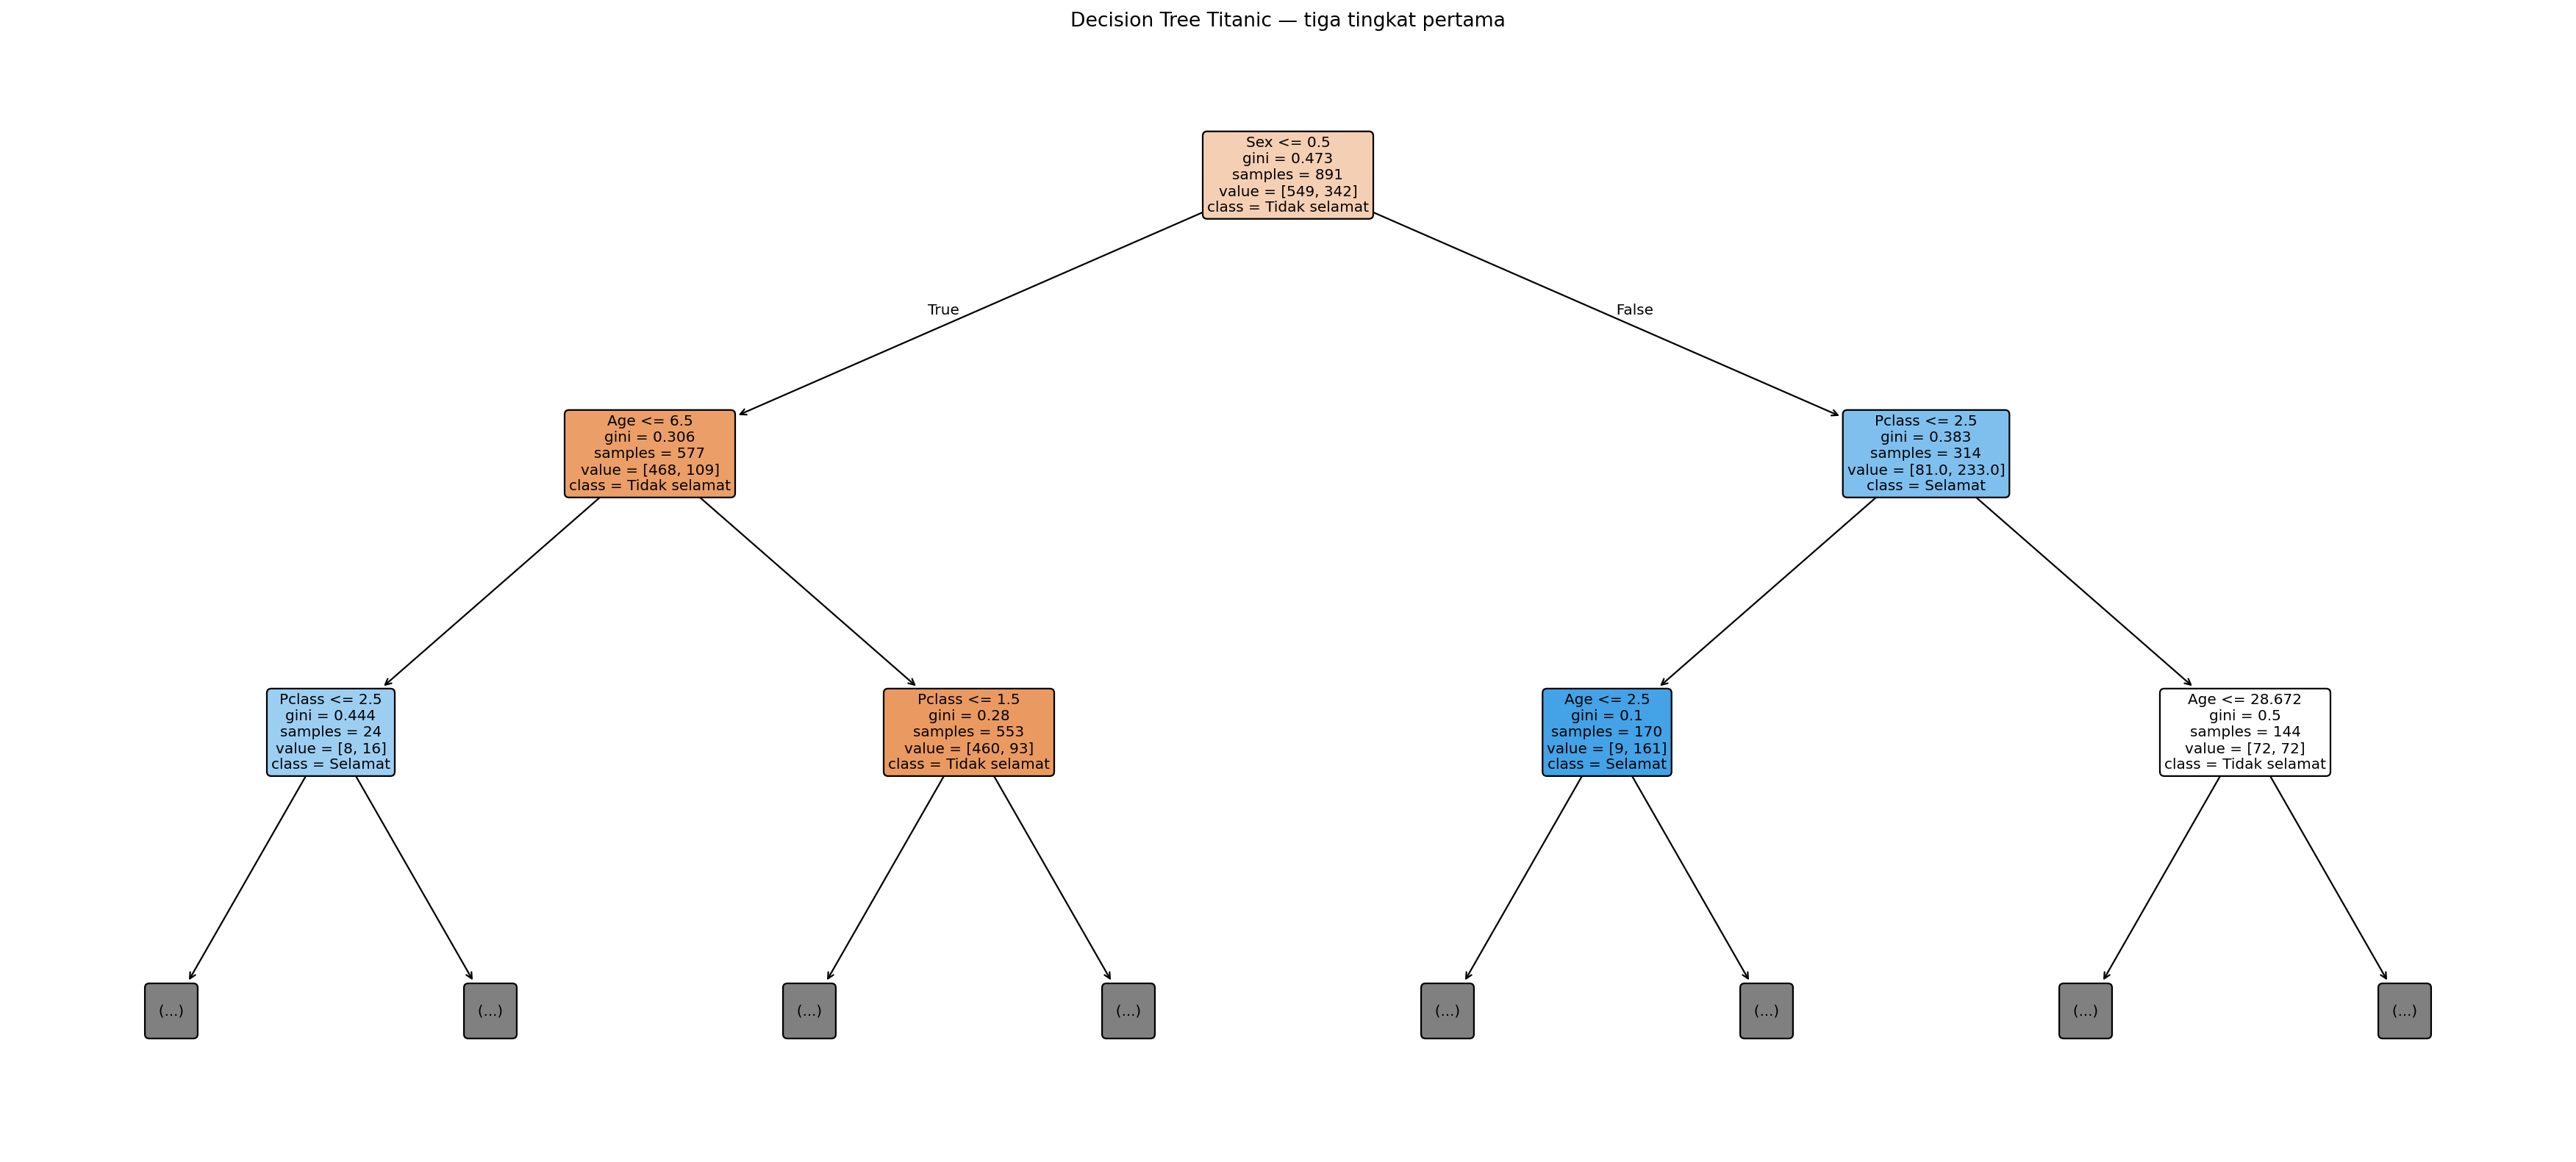

In [8]:
print('Kedalaman pohon:', model.get_depth())
print('Jumlah daun:', model.get_n_leaves())
print('Jumlah node:', model.tree_.node_count)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(model, feature_names=fitur,
          class_names=['Tidak selamat', 'Selamat'],
          filled=True, rounded=True, max_depth=2, fontsize=9, ax=ax)
ax.set_title('Decision Tree Titanic — tiga tingkat pertama')
fig.tight_layout()
fig.savefig('decision_tree_ringkas.png', dpi=160, bbox_inches='tight')
plt.show()

fig_lengkap, ax_lengkap = plt.subplots(figsize=(60, 30))
plot_tree(model, feature_names=fitur,
          class_names=['Tidak selamat', 'Selamat'],
          filled=True, rounded=True, fontsize=3, ax=ax_lengkap)
fig_lengkap.savefig('decision_tree_lengkap.pdf', bbox_inches='tight')
plt.close(fig_lengkap)

hierarki = export_text(model, feature_names=fitur,
                       max_depth=model.get_depth(), decimals=3)
with open('decision_tree_lengkap.txt', 'w', encoding='utf-8') as file:
    file.write(hierarki)
print('\nHierarki lengkap: decision_tree_lengkap.pdf dan decision_tree_lengkap.txt')

## Kesimpulan
Praktikum ini menerapkan Decision Tree untuk memprediksi Survived berdasarkan Sex, Age, Pclass, dan Fare. Missing values diisi dan Sex dikodekan menjadi angka sebelum klasifikasi. Pada 418 data test, model menghasilkan 91 prediksi salah, dengan error ratio 0.217703 (21.77%) dan akurasi 78.23%. Hierarki pohon menunjukkan aturan keputusan yang dipelajari model. Hasil ini diukur terhadap label pada titanic_testlabel.csv; label test hanya digunakan saat evaluasi.